In [16]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

result =llm.invoke('hi')
result.content

'How can I assist you today?'

## sequential workflow without LLm

{'weight_kg': 100, 'height_m': 2, 'bmi': 25.0, 'category': 'overWeight'}


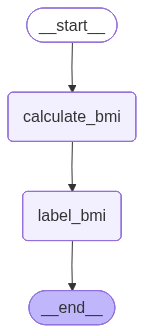

In [13]:
class BMIState(TypedDict):
    
    weight_kg: float
    height_m: float
    bmi: float
    category: str


def bmi_calculator (state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi,2)

    return state


def bmilabeler(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = "underWeight"
    elif 18.5<= bmi <25:
        state['category'] = "normal"
    elif 25<= bmi<30:
        state['category'] = 'overWeight'
    else:
        state['category']="Obese"

    return state



graph = StateGraph(BMIState)

graph.add_node('calculate_bmi',bmi_calculator)
graph.add_node('label_bmi',bmilabeler)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('label_bmi', END)

workflow = graph.compile()

final_state = workflow.invoke({'weight_kg':100, 'height_m':2})

print(final_state)

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

    


## sequential workflow with LLm

In [17]:
class LLmstate(TypedDict):
    question: str
    answer: str

In [18]:
def llm_qa(state: LLmstate)-> LLmstate:

    question = state['question']

    prompt = f"Answer the following {question}"

    answer = llm.invoke(prompt).content

    state['answer'] = answer
    return state

In [20]:
graph1 = StateGraph(LLmstate)

graph1.add_node('llm_qa',llm_qa)

graph1.add_edge(START,'llm_qa')
graph1.add_edge('llm_qa',END)

workflow1 = graph1.compile()

In [23]:
initial_state = {'question' : 'what is the distance between uk and france in km and miles ?'}

final_state = workflow1.invoke(initial_state)

print(final_state['answer'])

The distance between the UK and France varies depending on the specific locations. However, I'll provide you with the approximate distances between some major cities in the UK and France:

1. **London, UK to Paris, France:**
- Distance in kilometers: approximately 343 km (213 miles)
- Distance in miles: approximately 213 miles

2. **London, UK to Calais, France:**
- Distance in kilometers: approximately 215 km (134 miles)
- Distance in miles: approximately 134 miles

3. **Manchester, UK to Paris, France:**
- Distance in kilometers: approximately 560 km (348 miles)
- Distance in miles: approximately 348 miles

4. **Birmingham, UK to Paris, France:**
- Distance in kilometers: approximately 530 km (329 miles)
- Distance in miles: approximately 329 miles

Please note that these distances are approximate and may vary depending on the specific route taken.


## Prompt Chaining

In [24]:
class Blogstate(TypedDict):

    title: str
    outline: str
    content: str

In [26]:
def create_outline(state: Blogstate) -> Blogstate:

    title = state['title']

   
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = llm.invoke(prompt).content

   
    state['outline'] = outline

    return state


def create_blog(state: Blogstate) -> Blogstate:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

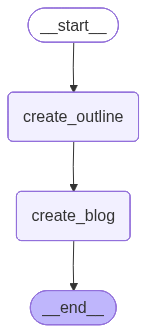

In [27]:
graph2 = StateGraph(Blogstate)


graph2.add_node('create_outline',create_outline)
graph2.add_node('create_blog',create_blog)

graph2.add_edge(START,'create_outline')
graph2.add_edge('create_outline','create_blog')
graph2.add_edge('create_blog',END)


workflow2= graph2.compile()
workflow2

In [29]:
intial_state = {'title': 'sarvam AI'}

final_state = workflow2.invoke(intial_state)

print(final_state['outline'])
print(final_state['content'])


**Title:** "Unlocking the Power of Sarvam AI: A Comprehensive Guide to its Applications and Benefits"

**I. Introduction**

* Brief overview of Sarvam AI and its significance
* Importance of AI in modern technology
* Thesis statement: Sarvam AI is a revolutionary technology that has the potential to transform various industries and aspects of our lives.

**II. What is Sarvam AI?**

* Definition and explanation of Sarvam AI
* History and evolution of Sarvam AI
* Key features and characteristics of Sarvam AI

**III. Applications of Sarvam AI**

* Healthcare:
 + Medical diagnosis and treatment
 + Personalized medicine
 + Telemedicine
* Finance:
 + Risk management
 + Portfolio optimization
 + Fraud detection
* Education:
 + Adaptive learning
 + Intelligent tutoring systems
 + Automated grading
* Other applications:
 + Customer service and support
 + Marketing and advertising
 + Supply chain management

**IV. Benefits of Sarvam AI**

* Increased efficiency and productivity
* Improved accura